In [1]:
# Load env variables and create client
from dotenv import load_dotenv
from anthropic import Anthropic

load_dotenv()

client = Anthropic()
model = "claude-sonnet-5"

In [2]:
# Helper functions — chat() goes through client.beta.messages because
# referencing uploaded files via container_upload requires the Files API beta
# (the code execution tool itself is GA and needs no beta header)
from pathlib import Path

from anthropic.types import Message
from anthropic.types.beta import BetaMessage


def add_user_message(messages, message):
    user_message = {
        "role": "user",
        "content": message.content
        if isinstance(message, (Message, BetaMessage))
        else message,
    }
    messages.append(user_message)


def add_assistant_message(messages, message):
    assistant_message = {
        "role": "assistant",
        "content": message.content
        if isinstance(message, (Message, BetaMessage))
        else message,
    }
    messages.append(assistant_message)


def chat(messages, system=None, tools=None):
    params = {
        "model": model,
        "max_tokens": 10000,
        "messages": messages,
        "betas": ["files-api-2025-04-14"],
    }

    if system:
        params["system"] = system

    if tools:
        params["tools"] = tools

    return client.beta.messages.create(**params)


def text_from_message(message):
    return "\n".join(block.text for block in message.content if block.type == "text")


def upload(file_path):
    path = Path(file_path)

    mime_type_map = {
        ".csv": "text/csv",
        ".json": "application/json",
        ".pdf": "application/pdf",
        ".png": "image/png",
        ".txt": "text/plain",
        ".xlsx": "application/vnd.openxmlformats-officedocument.spreadsheetml.sheet",
    }

    mime_type = mime_type_map.get(path.suffix.lower())
    if not mime_type:
        raise ValueError(f"Unknown mime type for extension: {path.suffix}")

    with open(path, "rb") as file:
        return client.beta.files.upload(file=(path.name, file, mime_type))


def get_metadata(file_id):
    return client.beta.files.retrieve_metadata(file_id)


def download_file(file_id, filename=None):
    file_content = client.beta.files.download(file_id)
    file_content.write_to_file(filename or get_metadata(file_id).filename)


def delete_file(file_id):
    return client.beta.files.delete(file_id)

In [3]:
# Upload the churn dataset once — the returned file_id can be referenced in
# any request without re-uploading the bytes
file_metadata = upload("streaming.csv")
file_metadata

FileMetadata(id='file_011Cd8WQieWEFq2oNWbTx8Bb', created_at=datetime.datetime(2026, 7, 17, 23, 36, 19, 238000, tzinfo=datetime.timezone.utc), filename='streaming.csv', mime_type='text/csv', size_bytes=25733, type='file', downloadable=False, scope=None)

In [4]:
# Ask Claude to analyze the dataset inside the sandboxed container.
# code_execution_20260120 gives Claude bash + file tools with REPL state that
# persists between executions, and the API runs every command server-side —
# there is no tool_result loop to implement. If the server-side loop hits its
# iteration limit, the response stops with stop_reason "pause_turn";
# re-sending the conversation resumes it where it left off
tools = [{"type": "code_execution_20260120", "name": "code_execution"}]

messages = []
add_user_message(
    messages,
    [
        {
            "type": "text",
            "text": (
                "Run a detailed analysis of this streaming-service dataset to "
                "determine the major drivers of churn. Summarize your findings "
                "in a single dashboard-style figure saved as "
                "churn_analysis_dashboard.png."
            ),
        },
        {"type": "container_upload", "file_id": file_metadata.id},
    ],
)

response = chat(messages, tools=tools)

while response.stop_reason == "pause_turn":
    add_assistant_message(messages, response)
    response = chat(messages, tools=tools)

print(text_from_message(response))

Excellent, very clear trends. Now let's build the dashboard figure.
Let me view the image to check layout quality before finalizing.
I've completed a detailed statistical analysis of the streaming dataset (500 subscribers, 38.6% overall churn rate) and packaged the findings into `churn_analysis_dashboard.png`. Here's a summary of the methodology and findings:

## Analysis performed
- **Descriptive stats & data quality check** — no missing values, 3 subscription tiers, 8 genres
- **Correlation analysis** between all numeric features and churn
- **T-tests** on every numeric feature (all significant, p<0.005)
- **Chi-square tests** on categorical features (SubscriptionTier significant p=0.009; TopGenre not significant, p=0.12)
- **Random Forest feature importance** (AUC≈0.85) and **logistic regression coefficients** to cross-validate driver ranking
- **Binned/quartile churn-rate breakdowns** for the strongest drivers (customer-service interactions, viewing hours)

## Key findings (visuali

In [5]:
# The response interleaves Claude's commentary with server_tool_use blocks
# (each command it ran) and their result blocks — a full trace of what
# happened inside the sandbox
for block in response.content:
    if block.type == "server_tool_use":
        preview = str(block.input).replace("\n", " ")[:110]
        print(f"[{block.name}] {preview}")
    elif block.type == "bash_code_execution_tool_result":
        result = block.content
        if result.type == "bash_code_execution_result":
            status = "ok" if result.return_code == 0 else f"exit {result.return_code}"
            created = [file.file_id for file in result.content]
            line = f"  -> bash result ({status})"
            print(line + (f" · created {created}" if created else ""))
        else:
            print(f"  -> tool error: {result.error_code}")
    elif block.type == "text_editor_code_execution_tool_result":
        print(f"  -> file operation: {block.content.type}")

[bash_code_execution] {'command': 'cd $INPUT_DIR && ls -la && echo "---" && head -5 streaming.csv && echo "---" && wc -l streaming.c
  -> bash result (ok)
[bash_code_execution] {'command': 'cd /tmp && cp $INPUT_DIR/streaming.csv . && python3 -c "\nimport pandas as pd\ndf = pd.read_csv(\
  -> bash result (ok)
[bash_code_execution] {'command': 'cd /tmp && python3 -c "\nimport pandas as pd\nimport numpy as np\nfrom scipy import stats\n\ndf =
  -> bash result (ok)
[bash_code_execution] {'command': 'cd /tmp && python3 -c "\nimport pandas as pd\nimport numpy as np\nfrom sklearn.linear_model impor
  -> bash result (ok)
[bash_code_execution] {'command': 'cd /tmp && python3 -c "\nimport pandas as pd\ndf = pd.read_csv(\'streaming.csv\')\n\n# Bin Custom
  -> bash result (ok)
[text_editor_code_execution] {'command': 'create', 'path': '/tmp/make_dashboard.py', 'file_text': 'import pandas as pd\nimport numpy as np\
  -> file operation: text_editor_code_execution_create_result
[bash_code_execution] {

In [6]:
# Files Claude created in the container surface as output blocks carrying a
# file_id — extract them and download through the Files API
def extract_file_ids(response):
    return [
        output.file_id
        for block in response.content
        if block.type == "bash_code_execution_tool_result"
        and block.content.type == "bash_code_execution_result"
        for output in block.content.content
    ]


generated_ids = extract_file_ids(response)

for file_id in generated_ids:
    filename = get_metadata(file_id).filename
    download_file(file_id, filename)
    print(f"Downloaded: {filename}")

Downloaded: churn_analysis_dashboard.png


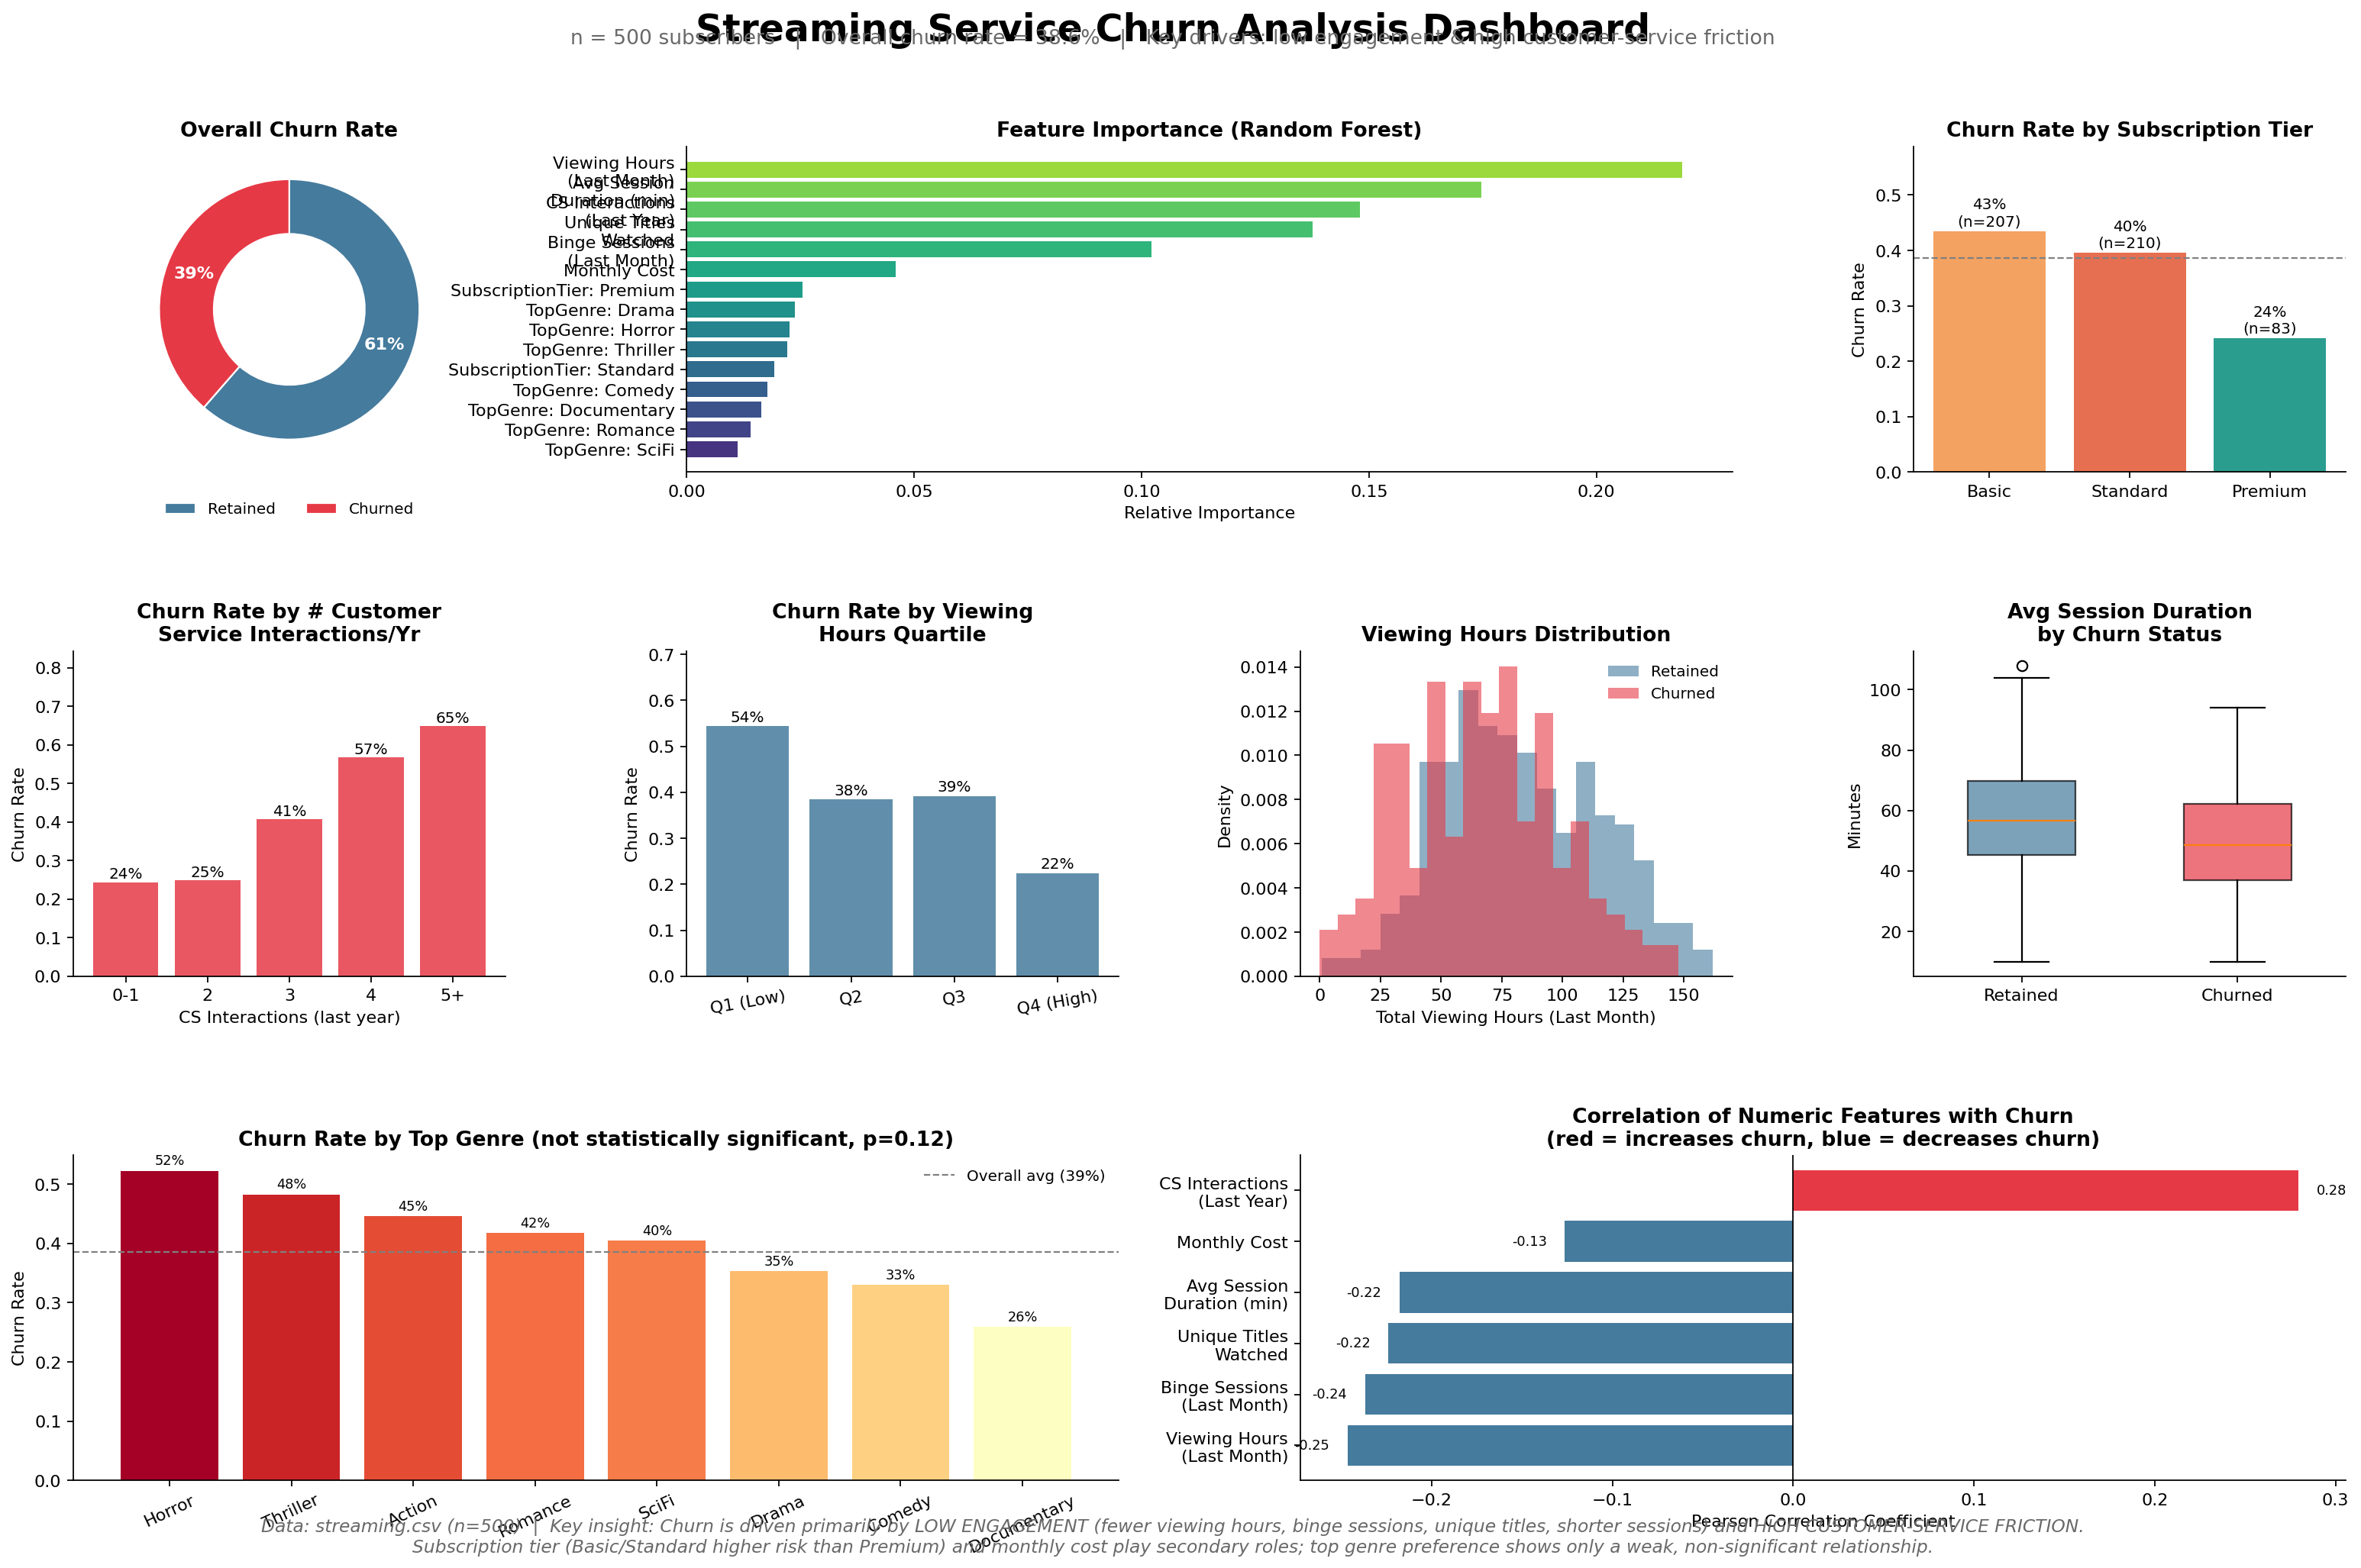

In [7]:
# The dashboard Claude built and saved inside the container
from IPython.display import Image

Image("churn_analysis_dashboard.png")

In [8]:
# Clean up file storage — uploaded and generated files persist until deleted
for file_id in [file_metadata.id, *generated_ids]:
    delete_file(file_id)